Model architecture: A hybrid DNN–LSTM model for detecting phishing URLs
Alper Ozcan1,2 • Cagatay Catal3 • Emrah Donmez4 • Behcet Senturk5

feature set using catchphish

latest phishtank archive 18/6/2025

D3 dataset (Alexa,Common Crawl/Phishtank): CatchPhish: detection of phishing websites by inspecting URLs
Routhu Srinivasa Rao1  · Tatti Vaishnavi2
 · Alwyn Roshan Pais1

 MTLP Dataset (Alexa/OpenPhish):
 Phishing Website Detection through Multi-Model Analysis of HTML Content.
Çolhak FEcevit MUçar BCreutzburg RDağ H

Ebbu2017 Dataset (Yandex/Phishtank): Machine learning based phishing detection from URLs
Ozgur Koray Sahingoz a,
, Ebubekir Buber b
, Onder Demir b
, Banu Diri

run with tpu

In [ ]:
# !pip install tensorflow==2.18.0
# !pip install tensorflow-tpu==2.18.0 --find-links=https://storage.googleapis.com/libtpu-tf-releases/index.html

# import tensorflow as tf

# try:
#     tpu = tf.distribute.cluster_resolver.TPUClusterResolver(tpu='local')
#     tf.config.experimental_connect_to_cluster(tpu)
#     tf.tpu.experimental.initialize_tpu_system(tpu)
#     strategy = tf.distribute.TPUStrategy(tpu)
#     print("TPU is running")
# except ValueError as e:
#     print("TPU is not avaible:", e)

Imports

In [ ]:
!pip install keras-tuner

In [ ]:
import pandas as pd
import tensorflow

from urllib.parse import urlparse
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# from tensorflow.keras.preprocessing.text import Tokenizer
# from tensorflow.keras.preprocessing.sequence import pad_sequences
# from tensorflow.keras.models import Model
# from tensorflow.keras.layers import Input, Dense, Dropout, Embedding, Bidirectional, LSTM, Concatenate
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.callbacks import EarlyStopping
# from tensorflow.keras.metrics import AUC

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
# from keras_tuner import HyperModel
# from keras_tuner.tuners import RandomSearch, Hyperband

import ipaddress
import re
import tldextract
import joblib
import pickle
import numpy as np

Dataset handling

In [3]:
!git clone "https://github.com/christopherevan/ClickSafe-Dataset" files

Cloning into 'files'...
remote: Enumerating objects: 165, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 165 (delta 4), reused 13 (delta 3), pack-reused 150 (from 1)
Receiving objects: 100% (165/165), 61.49 MiB | 41.13 MiB/s, done.
Resolving deltas: 100% (67/67), done.


In [ ]:
FEATURE_SETS = ['rao', 'sahingoz', 'tamal']
DATA_SETS = ['d3', 'ebbu', 'hannousse', 'mtlp']

TRAINING_FS_SELECT = FEATURE_SETS[0] # 0=RAO, 1=SAHINGOZ, 2=TAMAL
TRAINING_DATASET_SELECT = DATA_SETS[0] # 0=D3, 1=EBBU, 2=HANNOUSSE, 3=MTLP

bench_datasets_title = []
bench_datasets = []

path = "files/extracted/{}_with_{}_fs.csv".format(TRAINING_DATASET_SELECT, TRAINING_FS_SELECT)

print(TRAINING_FS_SELECT + ' training feature set selected')
print(TRAINING_DATASET_SELECT + ' training data set selected')
print('\nLoading test datasets ...')

train_df = pd.read_csv(path)

for ds in DATA_SETS:
  if (ds == TRAINING_DATASET_SELECT):
    continue
  else:
    test_path = "files/extracted/{}_with_{}_fs.csv".format(ds, TRAINING_FS_SELECT)
    test_df = pd.read_csv(test_path)
    
    bench_datasets_title.append(ds)
    bench_datasets.append(test_df)
    
    print('Test data loaded: ' + test_path)
    

sahingoz feature extraction selected


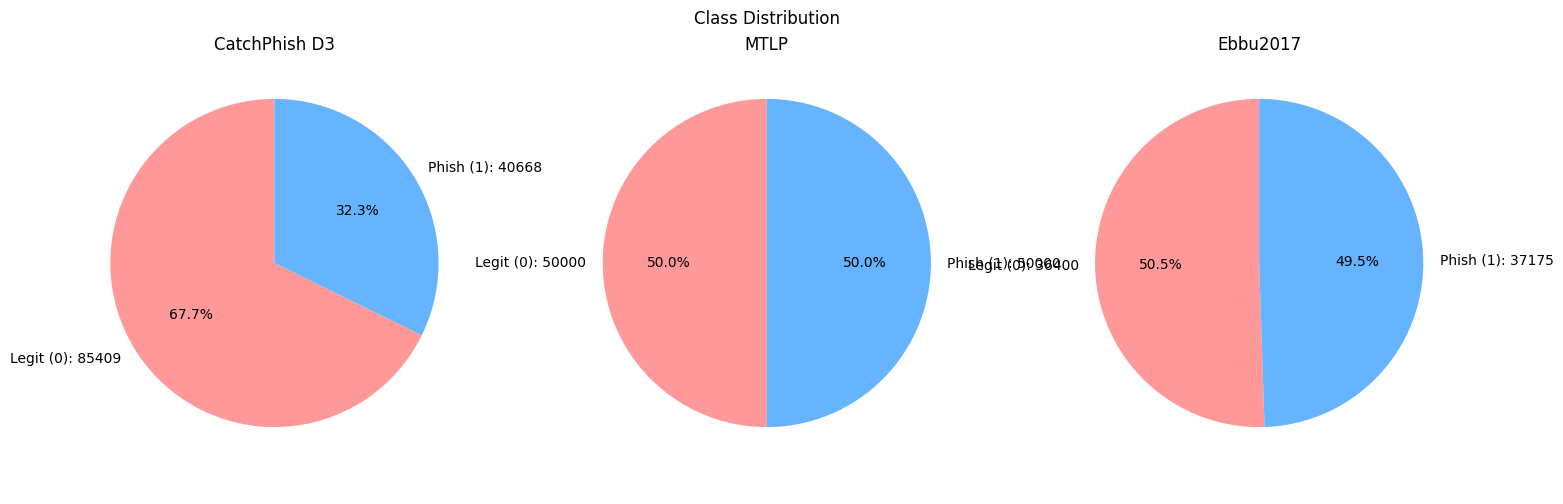

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 6))
plt.title('Class Distribution')
plt.axis('off')

d3_label_counts = d3['class'].value_counts()
d3_labels = [f'Legit (0): {d3_label_counts[0]}', f'Phish (1): {d3_label_counts[1]}']
plt.subplot(1,3,1)
plt.title('CatchPhish D3')
plt.pie(d3_label_counts, labels=d3_labels, autopct='%1.1f%%', startangle=90, colors=['#ff9999', '#66b3ff'])

mtlp_label_counts = mtlp['class'].value_counts()
mtlp_labels = [f'Legit (0): {mtlp_label_counts[0]}', f'Phish (1): {mtlp_label_counts[1]}']
plt.subplot(1,3,2)
plt.title('MTLP')
plt.pie(mtlp_label_counts, labels=mtlp_labels, autopct='%1.1f%%', startangle=90, colors=['#ff9999', '#66b3ff'])

ebbu_label_counts = ebbu['class'].value_counts()
ebbu_labels = [f'Legit (0): {ebbu_label_counts[0]}', f'Phish (1): {ebbu_label_counts[1]}']
plt.subplot(1,3,3)
plt.title('Ebbu2017')
plt.pie(ebbu_label_counts, labels=ebbu_labels, autopct='%1.1f%%', startangle=90, colors=['#ff9999', '#66b3ff'])


plt.show()

In [ ]:
# dropping duplicates
print('before: ' + str(d3.shape))
d3.drop_duplicates(inplace=True)
print('after: ' + str(d3.shape))

before: (126077, 2)
after: (125848, 2)


In [ ]:
print('before: ' + str(mtlp.shape))
mtlp.drop_duplicates(inplace=True)
print('after: ' + str(mtlp.shape))

before: (100000, 2)
after: (93831, 2)


In [ ]:
print('before: ' + str(ebbu.shape))
ebbu.drop_duplicates(inplace=True)
print('after: ' + str(ebbu.shape))

before: (73575, 2)
after: (54763, 2)


tokenize chars & convert to sequence

In [ ]:
def get_tokenizer(name, text):
    t = Tokenizer(char_level=True)
    t.fit_on_texts(text)
    
    with open(name, 'wb') as f:
        pickle.dump(t, f)
        
    return t

def get_scaler(name, data):
    scl = StandardScaler()
    scl.fit(data)
    joblib.dump((scl, data.columns.tolist()), name)
    
    return scl

def tokenize(tokenizer, text):
    char_seq = tokenizer.texts_to_sequences(text)
    X_char = pad_sequences(char_seq, maxlen=150, padding='post')
    return X_char

hyperparameter tuning

In [ ]:
def build_model(hp):
  # Lexical input branch
  input_lex = Input(shape=(X_lex_train.shape[1],), name='lex_input')
  x_lex = Dense(
      units=hp.Int('lex_dense1', min_value=64, max_value=512, step=64),
      activation='relu')(input_lex)
  x_lex = Dropout(rate=hp.Float('lex_dropout1', 0.2, 0.5, step=0.1))(x_lex)
  x_lex = Dense(
      units=hp.Int('lex_dense2', min_value=64, max_value=256, step=32),
      activation='relu')(x_lex)

  # Character sequence branch (BiLSTM)
  input_seq = Input(shape=(150,), name='char_input')
  x_seq = Embedding(input_dim=len(char_tokenizer.word_index) + 1, output_dim=128)(input_seq)
  x_seq = Bidirectional(LSTM(units=hp.Choice('lstm_units', [32, 64, 128])))(x_seq)
  x_seq = Dropout(rate=hp.Float('seq_dropout', 0.2, 0.5, step=0.1))(x_seq)

  # Optional HT layer for sequence
  if hp.Boolean('use_ht_seq'):
      x_seq = Dense(units=hp.Int('seq_ht_units', 8, 64, step=8), activation='relu')(x_seq)

  # Merge
  merged = Concatenate()([x_lex, x_seq])
  merged = Dense(units=hp.Int('merged_dense', 64, 256, step=32), activation='relu')(merged)
  merged = Dropout(rate=hp.Float('merged_dropout', 0.2, 0.5, step=0.1))(merged)

  # Optional HT layer for merged
  if hp.Boolean('use_ht_merged'):
      merged = Dense(units=hp.Int('merged_ht_units', 8, 64, step=8), activation='relu')(merged)

  output = Dense(1, activation='sigmoid')(merged)

  model = Model(inputs=[input_lex, input_seq], outputs=output)

  model.compile(
      optimizer=Adam(),
      loss='binary_crossentropy',
      metrics=['accuracy', AUC()])

  return model

In [ ]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

labels = np.array(train_df["class"].values)
urls = np.array(train_df["url"].values)
lex_features = np.array(train_df.drop(columns=["class", "url"]))

X_char_bench_datasets = []
X_lex_scaled_bench_datasets = []
y_bench_datasets = []

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

for fold, (train_index, test_index) in enumerate(skf.split(lex_features, labels), 1):
    X_lex_train, X_lex_test = lex_features[train_index], lex_features[test_index]
    urls_train, urls_test = urls[train_index], urls[test_index]
    y_train, y_test = labels[train_index], labels[test_index]
    
    fold_info = "fold_{}_{}_{}_fs".format(fold, TRAINING_DATASET_SELECT, TRAINING_FS_SELECT)
    print(f"Fold info: {fold_info}")

    TOKENIZER_NAME = "{}_tokenizer.pkl".format(fold_info)
    char_tokenizer = get_tokenizer(TOKENIZER_NAME, urls_train)
    X_char_train = tokenize(char_tokenizer, urls_train)
    X_char_test = tokenize(char_tokenizer, urls_test)

    SCALER_NAME = "{}_scaler.pkl".format(fold_info)
    scaler = get_scaler(SCALER_NAME, X_lex_train)
    X_lex_train_scaled = scaler.transform(X_lex_train)
    X_lex_test_scaled  = scaler.transform(X_lex_test)
        
    tuner = Hyperband(
        hypermodel=build_model,
        objective='val_accuracy',
        max_epochs=50,
        factor=3,
        hyperband_iterations=1,
        seed=42,
        directory='tuner_results',
        project_name='phishing_detection'
    )

    tuner.search(
        [X_lex_train_scaled, X_char_train], y_train,
        validation_data=([X_lex_test_scaled, X_char_test], y_test),
        batch_size=128,
        callbacks=[early_stop]
    )
    
    best_model = tuner.get_best_models(num_models=1)[0]
    best_model.summary()
    best_model_name = fold_info + "best_model.keras"
    best_model.save(best_model_name)
    
    fold_ht_bst_name = "{}_result_summary.txt".format(fold_info)
    with open(fold_ht_bst_name, "w") as f:
        f.write(tuner.results_summary())
    
    
    for idx, d in enumerate(bench_datasets):
        X_char = tokenize(char_tokenizer, d['url'])
        X_lex_scaled = scaler.transform(d.drop(columns=['class', 'url']))
        
        X_char_bench_datasets.append(X_char)
        X_lex_scaled_bench_datasets.append(X_lex_scaled)
        y_bench_datasets.append(d['class'])
        
        y_pred = best_model.predict([X_lex_scaled_bench_datasets, X_char_bench_datasets])
        y_pred_classes = (y_pred > 0.5).astype(int)
        
        eval_name = "{}_on_{}_evaluation.txt".format(bench_datasets_title[idx], fold_info)
        with open(eval_name, "w") as f:
            # Confusion Matrix
            f.write("Confusion Matrix:\n")
            f.write(str(confusion_matrix(y_bench_datasets, y_pred_classes)) + "\n\n")
            
            # Classification Report
            f.write("Classification Report:\n")
            f.write(classification_report(y_bench_datasets, y_pred_classes, digits=4) + "\n")
            
            # ROC AUC Score
            auc = roc_auc_score(y_bench_datasets, y_pred)
            f.write(f"ROC AUC Score: {auc:.4f}\n")
        
        
        


In [ ]:
!zip -r tuner_results.zip tuner_results

  adding: tuner_results/ (stored 0%)
  adding: tuner_results/phishing_detection/ (stored 0%)
  adding: tuner_results/phishing_detection/trial_0072/ (stored 0%)
  adding: tuner_results/phishing_detection/trial_0072/trial.json (deflated 77%)
  adding: tuner_results/phishing_detection/trial_0072/checkpoint.weights.h5 (deflated 8%)
  adding: tuner_results/phishing_detection/trial_0072/build_config.json (stored 0%)
  adding: tuner_results/phishing_detection/trial_0087/ (stored 0%)
  adding: tuner_results/phishing_detection/trial_0087/trial.json (deflated 77%)
  adding: tuner_results/phishing_detection/trial_0087/checkpoint.weights.h5 (deflated 8%)
  adding: tuner_results/phishing_detection/trial_0087/build_config.json (stored 0%)
  adding: tuner_results/phishing_detection/trial_0034/ (stored 0%)
  adding: tuner_results/phishing_detection/trial_0034/trial.json (deflated 77%)
  adding: tuner_results/phishing_detection/trial_0034/checkpoint.weights.h5 (deflated 9%)
  adding: tuner_results/phis

In [ ]:
for trial_id, trial in tuner.oracle.trials.items():
    print(f"Trial {trial_id}:")
    print(f"  Score: {trial.score}")
    print(f"  Hyperparameters: {trial.hyperparameters.values}")
    print()

Trial 0000:
  Score: 0.938464343547821
  Hyperparameters: {'lex_dense1': 384, 'lex_dropout1': 0.2, 'lex_dense2': 128, 'lstm_units': 32, 'seq_dropout': 0.4, 'use_ht_seq': False, 'merged_dense': 160, 'merged_dropout': 0.2, 'use_ht_merged': False, 'tuner/epochs': 2, 'tuner/initial_epoch': 0, 'tuner/bracket': 3, 'tuner/round': 0}

Trial 0001:
  Score: 0.9294257164001465
  Hyperparameters: {'lex_dense1': 128, 'lex_dropout1': 0.4, 'lex_dense2': 192, 'lstm_units': 128, 'seq_dropout': 0.2, 'use_ht_seq': True, 'merged_dense': 64, 'merged_dropout': 0.30000000000000004, 'use_ht_merged': False, 'tuner/epochs': 2, 'tuner/initial_epoch': 0, 'tuner/bracket': 3, 'tuner/round': 0, 'seq_ht_units': 8}

Trial 0002:
  Score: 0.9305213093757629
  Hyperparameters: {'lex_dense1': 192, 'lex_dropout1': 0.30000000000000004, 'lex_dense2': 256, 'lstm_units': 64, 'seq_dropout': 0.30000000000000004, 'use_ht_seq': False, 'merged_dense': 64, 'merged_dropout': 0.2, 'use_ht_merged': True, 'seq_ht_units': 48, 'tuner/epoc

In [ ]:
tuner.results_summary()

Results summary
Results in tuner_results/phishing_detection
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 0082 summary
Hyperparameters:
lex_dense1: 384
lex_dropout1: 0.30000000000000004
lex_dense2: 160
lstm_units: 128
seq_dropout: 0.2
use_ht_seq: False
merged_dense: 96
merged_dropout: 0.2
use_ht_merged: True
seq_ht_units: 32
merged_ht_units: 40
tuner/epochs: 50
tuner/initial_epoch: 17
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0077
Score: 0.985268235206604

Trial 0086 summary
Hyperparameters:
lex_dense1: 128
lex_dropout1: 0.2
lex_dense2: 192
lstm_units: 32
seq_dropout: 0.4
use_ht_seq: True
merged_dense: 128
merged_dropout: 0.30000000000000004
use_ht_merged: False
seq_ht_units: 32
merged_ht_units: 24
tuner/epochs: 50
tuner/initial_epoch: 0
tuner/bracket: 0
tuner/round: 0
Score: 0.9846013784408569

Trial 0051 summary
Hyperparameters:
lex_dense1: 512
lex_dropout1: 0.2
lex_dense2: 64
lstm_units: 32
seq_dropout: 0.2
use_ht_seq: False
merged_dense: 128
me

In [ ]:
best_model = tuner.get_best_models(num_models=1)[0]
best_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ lex_input           │ (None, 35)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_input          │ (None, 150)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 384)       │     13,824 │ lex_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 150, 128)  │     11,392 │ char_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 384)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 256)       │    263,168 │ embedding[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 160)       │     61,600 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 416)       │          0 │ dense_1[0][0],    │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 96)        │     40,032 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 96)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 40)        │      3,880 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │         41 │ dense_3[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 393,937 (1.50 MB)

 Trainable params: 393,937 (1.50 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
y_pred = best_model.predict([X_lex_test_scaled, X_char_test])
y_pred_classes = (y_pred > 0.5).astype(int)

# Metrics
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_classes))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes, digits=4))

auc = roc_auc_score(y_test, y_pred_classes)
print(f"\nROC AUC Score: {auc:.4f}")

516/516 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step
Confusion Matrix:
[[ 5875   107]
 [  136 10377]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9774    0.9821    0.9797      5982
           1     0.9898    0.9871    0.9884     10513

    accuracy                         0.9853     16495
   macro avg     0.9836    0.9846    0.9841     16495
weighted avg     0.9853    0.9853    0.9853     16495


ROC AUC Score: 0.9846


In [ ]:
y_pred_d3 = best_model.predict([X_lex_d3_scaled, X_char_d3])
y_pred_classes_d3 = (y_pred_d3 > 0.5).astype(int)

# Metrics
print("Confusion Matrix:")
print(confusion_matrix(y_d3, y_pred_classes_d3))

print("\nClassification Report:")
print(classification_report(y_d3, y_pred_classes_d3, digits=4))

auc = roc_auc_score(y_d3, y_pred_d3)
print(f"\nROC AUC Score: {auc:.4f}")

4310/4310 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step
Confusion Matrix:
[[52016 33327]
 [  357 52204]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9932    0.6095    0.7554     85343
           1     0.6104    0.9932    0.7561     52561

    accuracy                         0.7557    137904
   macro avg     0.8018    0.8014    0.7557    137904
weighted avg     0.8473    0.7557    0.7557    137904


ROC AUC Score: 0.9353


In [ ]:
y_pred_ebbu = best_model.predict([X_lex_ebbu_scaled, X_char_ebbu])
y_pred_classes_ebbu = (y_pred_ebbu > 0.5).astype(int)

# Metrics
print("Confusion Matrix:")
print(confusion_matrix(y_ebbu, y_pred_classes_ebbu))

print("\nClassification Report:")
print(classification_report(y_ebbu, y_pred_classes_ebbu, digits=4))

auc = roc_auc_score(y_ebbu, y_pred_ebbu)
print(f"\nROC AUC Score: {auc:.4f}")

2578/2578 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step
Confusion Matrix:
[[28994   916]
 [ 1651 50910]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9461    0.9694    0.9576     29910
           1     0.9823    0.9686    0.9754     52561

    accuracy                         0.9689     82471
   macro avg     0.9642    0.9690    0.9665     82471
weighted avg     0.9692    0.9689    0.9690     82471


ROC AUC Score: 0.9929


In [ ]:
y_pred_mtlp = best_model.predict([X_lex_mtlp_scaled, X_char_mtlp])
y_pred_classes_mtlp = (y_pred_mtlp > 0.5).astype(int)

# Metrics
print("Confusion Matrix:")
print(confusion_matrix(y_mtlp, y_pred_classes_mtlp))

print("\nClassification Report:")
print(classification_report(y_mtlp, y_pred_classes_mtlp, digits=4))

auc = roc_auc_score(y_mtlp, y_pred_mtlp)
print(f"\nROC AUC Score: {auc:.4f}")

2933/2933 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step
Confusion Matrix:
[[19812 27697]
 [ 8127 38195]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7091    0.4170    0.5252     47509
           1     0.5797    0.8246    0.6808     46322

    accuracy                         0.6182     93831
   macro avg     0.6444    0.6208    0.6030     93831
weighted avg     0.6452    0.6182    0.6020     93831


ROC AUC Score: 0.6118
